# AI, Machine Learning, Deep Learning & Data Science
## Complete notes: foundations, learning techniques, examples, code, and revision

These notes turn the supplied transcript and handwritten PDF pages into a clean learning path. The language is simple, but the ideas are technically accurate.

### What you will learn

- The difference between **Artificial Intelligence (AI), Machine Learning (ML), Deep Learning (DL), and Data Science (DS)**
- The three main learning settings: **supervised, unsupervised, and reinforcement learning**
- Inputs, outputs, features, labels, regression, classification, and clustering
- Where common algorithms such as Linear Regression, Logistic Regression, Random Forest, K-Means, and DBSCAN fit
- How to choose the right technique for a new problem

> **Source scope:** `Pasted text(20260911-205740).txt`, `1-AIVMLVSDLVSDS.pdf`, and `2-Typesof+ML+technqiues.pdf`.

## Goal

By the end, you should be able to look at a problem and answer:

1. Is this mainly AI, ML, DL, or data science?
2. Does the dataset have a known target?
3. Is the task regression, classification, clustering, or reinforcement learning?
4. Which basic algorithm family is a sensible starting point?

## Setup

The examples use standard Python data tools and scikit-learn. Run the notebook from top to bottom. A fixed random seed keeps the results reproducible.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Setup complete. Random seed:", RANDOM_SEED)

Setup complete. Random seed: 42


# Part 1 — AI vs ML vs DL vs Data Science

## 1. Artificial Intelligence (AI)

**Artificial Intelligence is the broad goal of building systems that perform tasks that normally require human intelligence.**

Examples include:

- recommending a movie;
- understanding speech;
- recognizing an object in an image;
- planning a route;
- making a driving decision.

The transcript describes AI as an application that performs a task without human intervention. That is a useful starting idea, but AI does **not** always mean complete independence. Many AI systems assist a person or require human supervision.

### Examples from the lesson

- **Netflix recommendation:** past viewing behaviour helps the system recommend similar content.
- **Online shopping recommendation:** browsing or purchase history helps suggest products.
- **Self-driving functions:** cameras and sensors help detect roads, objects, and traffic lights.

## 2. Machine Learning (ML)

**Machine Learning is a way to build AI systems by learning patterns from data instead of writing every rule manually.**

A traditional rule might say:

> If a customer watches three action movies, recommend another action movie.

An ML model instead studies many examples and learns which viewing patterns usually lead to which recommendations.

ML commonly helps us:

- analyse patterns;
- predict a number or category;
- forecast future values;
- rank or recommend items;
- detect unusual behaviour;
- group similar records.

Machine learning uses ideas from statistics, mathematics, optimization, and computer science.

## 3. Deep Learning (DL)

**Deep Learning is a part of machine learning that uses neural networks with multiple layers.**

These networks are loosely inspired by biological neurons, but they are **not copies of the human brain**. They learn useful representations by adjusting many numerical parameters during training.

Deep learning is especially useful for complex, high-dimensional data such as:

- images and video;
- speech and audio;
- natural language;
- large-scale recommendation systems.

It often needs more data and computing power than simpler ML methods. A simpler method may be better for a small tabular dataset.

## 4. Data Science (DS)

**Data Science is the wider practice of using data to answer questions, produce insights, and support decisions.**

A data scientist may work on:

- collecting and cleaning data;
- exploratory data analysis (EDA);
- visualization and reporting;
- statistics and experiments;
- feature engineering;
- machine-learning or deep-learning models;
- deploying or communicating results.

Data science overlaps ML, DL, and AI, but not every data-science task is AI. For example, a dashboard that summarizes last month's sales is data science even if it contains no predictive model.

## 5. The relationship — the accurate mental model

| Term | Main purpose | Learns from data? | Typical output |
|---|---|---:|---|
| **AI** | Build systems that perform intelligent tasks | Sometimes | Decision, action, recommendation, generated result |
| **ML** | Learn patterns from examples | Yes | Prediction, score, group, recommendation |
| **DL** | Learn complex patterns using multilayer neural networks | Yes | Image/text/audio prediction or generation |
| **Data Science** | Understand data and support decisions | Sometimes | Insight, report, experiment, model, dashboard |

The safest relationship to remember is:

- **Deep Learning ⊂ Machine Learning ⊂ Artificial Intelligence**
- **Data Science overlaps with ML/AI**, but it is not simply a smaller circle inside AI.

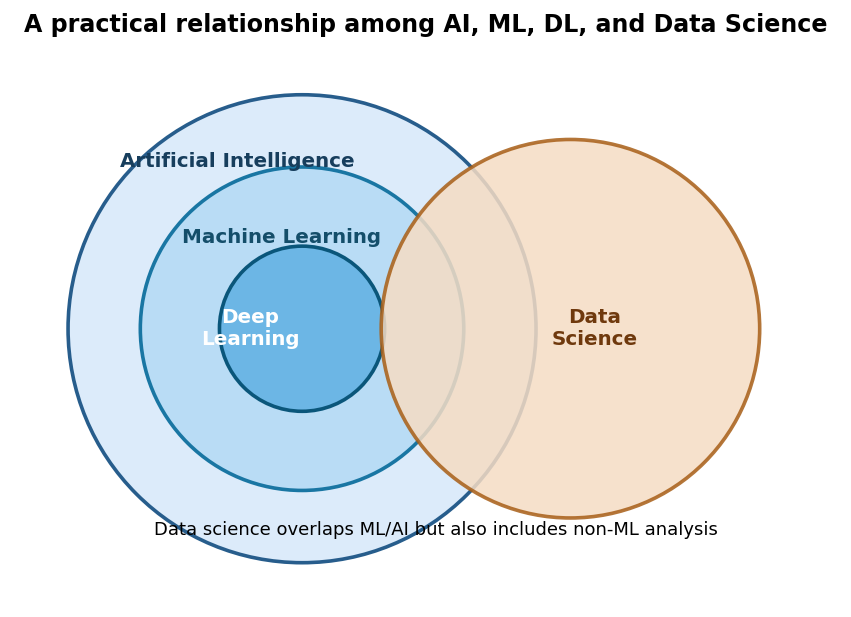

In [2]:
# A visual mental model of the relationship
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.set_aspect("equal")
ax.axis("off")

ai = Circle((4.2, 4), 3.4, facecolor="#DCEBFA", edgecolor="#275D8C", linewidth=2)
ml = Circle((4.2, 4), 2.35, facecolor="#B9DCF5", edgecolor="#1976A3", linewidth=2)
dl = Circle((4.2, 4), 1.20, facecolor="#6CB6E5", edgecolor="#0A567A", linewidth=2)
ds = Circle((8.1, 4), 2.75, facecolor="#F5DCC4", edgecolor="#A85F18", linewidth=2, alpha=0.86)

for shape in (ai, ml, dl, ds):
    ax.add_patch(shape)

ax.text(1.55, 6.35, "Artificial Intelligence", weight="bold", color="#173E5D")
ax.text(2.45, 5.25, "Machine Learning", weight="bold", color="#144E6A")
ax.text(3.45, 4.0, "Deep\nLearning", ha="center", va="center", weight="bold", color="white")
ax.text(8.45, 4.0, "Data\nScience", ha="center", va="center", weight="bold", color="#6F390D")
ax.text(6.15, 1.0, "Data science overlaps ML/AI but also includes non-ML analysis", ha="center", fontsize=10)
plt.title("A practical relationship among AI, ML, DL, and Data Science", pad=12, weight="bold")
plt.show()

### One problem viewed through all four terms

Suppose an online video platform recommends a film:

- **AI:** the complete intelligent recommendation experience;
- **ML:** the model learns viewing patterns from user data;
- **DL:** a neural network may learn complex user and movie representations;
- **Data Science:** analysts clean data, study engagement, define success metrics, test the system, and explain results.

# Part 2 — The three major machine-learning settings

| Setting | Is a correct target supplied? | What does the model learn? | Example |
|---|---:|---|---|
| **Supervised learning** | Yes | A mapping from inputs to a target | Predict house price |
| **Unsupervised learning** | No | Structure or patterns in the inputs | Group similar customers |
| **Reinforcement learning** | No fixed answer per row; feedback arrives as rewards | A strategy for choosing actions | Learn how to play a game |

> A fourth setting often seen in modern courses is **semi-supervised learning**, which mixes a small labelled dataset with a larger unlabelled dataset. The supplied lesson focuses on the three settings above.

## 6. Supervised Learning

In supervised learning, every training example contains:

- **input features** ($X$): the information used to make a prediction;
- **target / label** ($y$): the correct answer the model should learn to predict.

### House-price example

| House size (sq ft) | Number of rooms | Price |
|---:|---:|---:|
| 5,000 | 5 | 450,000 |
| 6,000 | 6 | 500,000 |

Here, size and rooms are **independent/input features**. Price is the **dependent/output feature**. The word *dependent* means that it is the value we want to explain or predict using the inputs; it does not prove a causal relationship.

Mathematically:

$$X = [\text{size},\ \text{rooms}], \qquad y = \text{price}$$

### 6.1 Regression

Use **regression** when the target is a numerical quantity for which differences have meaning.

Examples:

- house price;
- temperature tomorrow;
- monthly sales;
- delivery time.

A useful rule is “numeric target → consider regression,” but do not use only the data type. A postal code may be stored as a number but is actually a category.

In [3]:
# Mini regression example: predict a house price
house_data = pd.DataFrame({
    "size_sqft": [900, 1200, 1500, 1800, 2200, 2600, 3000],
    "rooms":     [2,   2,    3,    3,    4,    4,    5],
    "price_k":   [135, 165, 210, 245, 305, 350, 410],
})

X_house = house_data[["size_sqft", "rooms"]]
y_house = house_data["price_k"]

regression_model = LinearRegression()
regression_model.fit(X_house, y_house)

new_house = pd.DataFrame({"size_sqft": [2000], "rooms": [3]})
predicted_price = regression_model.predict(new_house)[0]

display(house_data)
print(f"Predicted price for a 2,000 sq ft, 3-room house: {predicted_price:.1f} thousand")

,size_sqft,rooms,price_k
0,900,2,135
1,1200,2,165
2,1500,3,210
3,1800,3,245
4,2200,4,305
5,2600,4,350
6,3000,5,410


Predicted price for a 2,000 sq ft, 3-room house: 268.7 thousand


The model learns a line or plane that best connects the input features to price. This is a teaching example, not a real property valuation: real prices also depend on location, age, condition, and many other variables.

### 6.2 Classification

Use **classification** when the target is a category.

- **Binary classification:** exactly two classes, such as pass/fail, spam/not spam, fraud/not fraud.
- **Multiclass classification:** more than two mutually exclusive classes, such as low/medium/high risk or cat/dog/bird.
- **Multilabel classification (advanced distinction):** one item can have several labels at once, such as a photo tagged `beach`, `sunset`, and `people`.

The lesson uses study hours and play hours to predict pass or fail.

In [4]:
# Mini binary-classification example: Pass = 1, Fail = 0
student_data = pd.DataFrame({
    "study_hours": [1, 2, 2, 3, 4, 5, 6, 7, 8, 9],
    "play_hours":  [8, 7, 6, 6, 5, 4, 4, 3, 2, 2],
    "passed":      [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
})

X_student = student_data[["study_hours", "play_hours"]]
y_student = student_data["passed"]

classification_model = LogisticRegression(random_state=RANDOM_SEED)
classification_model.fit(X_student, y_student)

new_student = pd.DataFrame({"study_hours": [7], "play_hours": [3]})
pass_probability = classification_model.predict_proba(new_student)[0, 1]
predicted_class = classification_model.predict(new_student)[0]

display(student_data)
print(f"Predicted class: {'Pass' if predicted_class == 1 else 'Fail'}")
print(f"Estimated probability of passing: {pass_probability:.1%}")

,study_hours,play_hours,passed
0,1,8,0
1,2,7,0
2,2,6,0
3,3,6,0
4,4,5,0
5,5,4,1
6,6,4,1
7,7,3,1
8,8,2,1
9,9,2,1


Predicted class: Pass
Estimated probability of passing: 96.8%


### Supervised-learning workflow

1. Define the target clearly.
2. Collect labelled examples.
3. Separate inputs ($X$) and target ($y$).
4. Split data into training, validation, and test sets.
5. Train the model on the training set.
6. Tune choices using validation data or cross-validation.
7. Evaluate once on unseen test data.
8. Deploy, monitor errors, and retrain when the data changes.

**Important:** having a target makes the problem supervised; it does not automatically make the data correct or the prediction useful.

## 7. Unsupervised Learning

In unsupervised learning, the dataset has input features but no supplied target label. The aim is to discover structure.

Common goals include:

- **clustering:** group similar records;
- **dimensionality reduction:** represent many features using fewer dimensions;
- **anomaly detection:** find unusual records;
- **association discovery:** find items that often occur together.

### Customer-segmentation example

The lesson uses salary/income and a spending score. We are **not** predicting the spending score from salary. We use both variables to find groups of customers with similar behaviour.

,income_k,spending_score,cluster
0,20,9,0
1,22,8,0
2,45,7,0
3,42,8,0
4,78,4,1
5,82,3,1
6,28,2,2
7,25,3,2
8,52,2,2
9,48,3,2


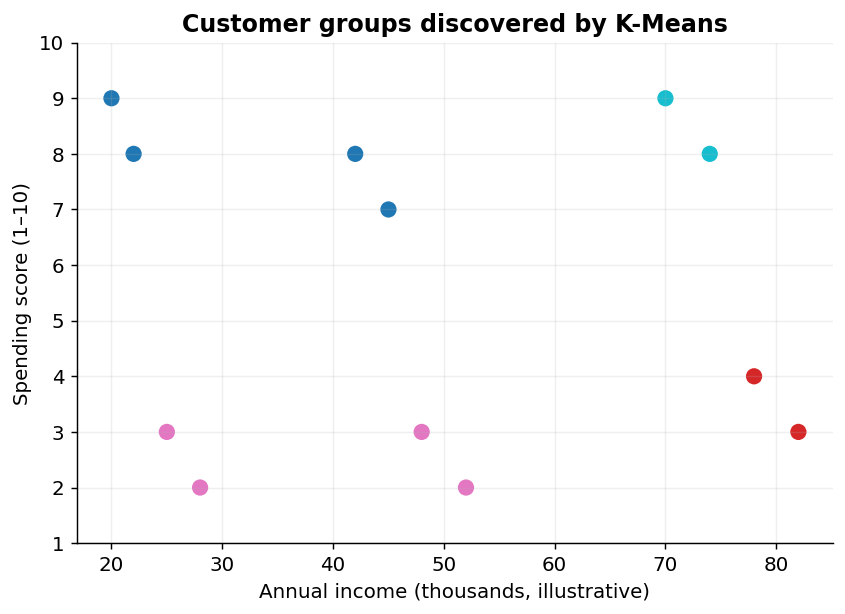

In [5]:
# Mini clustering example: customer segmentation with K-Means
customer_data = pd.DataFrame({
    "income_k":      [20, 22, 25, 28, 42, 45, 48, 52, 70, 74, 78, 82],
    "spending_score": [9,  8,  3,  2,  8,  7,  3,  2,  9,  8,  4,  3],
})

# Scaling prevents the larger-numbered feature from dominating distance.
scaler = StandardScaler()
customer_scaled = scaler.fit_transform(customer_data)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
customer_data["cluster"] = kmeans.fit_predict(customer_scaled)

display(customer_data.sort_values("cluster").reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7.5, 5))
scatter = ax.scatter(
    customer_data["income_k"],
    customer_data["spending_score"],
    c=customer_data["cluster"],
    cmap="tab10",
    s=100,
    edgecolor="white",
    linewidth=1,
)
ax.set_title("Customer groups discovered by K-Means", weight="bold")
ax.set_xlabel("Annual income (thousands, illustrative)")
ax.set_ylabel("Spending score (1–10)")
ax.set_yticks(range(1, 11))
plt.show()

The cluster numbers are only IDs; cluster `0` is not automatically better than cluster `1`. A business must inspect each group's centre and behaviour before deciding how to communicate with it.

For example, a high-income/high-spending group may respond to premium launches, while a high-income/low-spending group may need a different offer. This is a business interpretation, not something the algorithm knows by itself.

### Common clustering algorithms

| Algorithm | Main idea | Useful when | Main caution |
|---|---|---|---|
| **K-Means** | Assign points to the nearest centre | Groups are compact and roughly round | Must choose $K$; sensitive to scale and outliers |
| **Hierarchical clustering** | Repeatedly merge or split groups | You want a hierarchy/dendrogram | Can be expensive on large data |
| **DBSCAN** | Find dense regions and mark sparse points as noise | Clusters have irregular shapes; outliers matter | Sensitive to distance settings and scale |

The transcript says “hierarchical mean”; the standard name is **hierarchical clustering**.

## 8. Reinforcement Learning (RL)

Reinforcement learning is about **learning what action to take through interaction and reward feedback**.

Key terms:

| Term | Meaning |
|---|---|
| **Agent** | The learner or decision-maker |
| **Environment** | The world in which the agent acts |
| **State** | The current situation |
| **Action** | A choice available to the agent |
| **Reward** | Feedback received after an action |
| **Policy** | The agent's strategy for choosing actions |
| **Episode** | One complete run, such as one game |

The child-learning-to-walk example from the lesson gives the basic intuition: actions have consequences, and experience changes future behaviour. In an RL system, rewards are numeric signals designed by the developer.

Examples:

- game-playing agents;
- robot movement;
- traffic-signal control;
- sequential recommendation or ad selection;
- resource allocation.

In [6]:
# Tiny reinforcement-learning intuition: an epsilon-greedy multi-armed bandit
# Three actions have unknown average rewards. The agent learns which action is best.
true_reward_probabilities = np.array([0.20, 0.55, 0.80])
estimated_values = np.zeros(3)
action_counts = np.zeros(3, dtype=int)
epsilon = 0.10
total_reward = 0

for step in range(1, 501):
    explore = np.random.random() < epsilon
    if explore:
        action = np.random.randint(3)
    else:
        action = int(np.argmax(estimated_values))

    reward = float(np.random.random() < true_reward_probabilities[action])
    action_counts[action] += 1
    total_reward += reward

    # Incremental update of the estimated average reward for this action
    estimated_values[action] += (
        reward - estimated_values[action]
    ) / action_counts[action]

bandit_results = pd.DataFrame({
    "action": ["A", "B", "C"],
    "times_selected": action_counts,
    "estimated_average_reward": estimated_values.round(3),
    "true_reward_probability": true_reward_probabilities,
})

display(bandit_results)
print("Total reward after 500 steps:", int(total_reward))
print("Learned best action:", ["A", "B", "C"][int(np.argmax(estimated_values))])

,action,times_selected,estimated_average_reward,true_reward_probability
0,A,29,0.207,0.20
1,B,16,0.562,0.55
2,C,455,0.793,0.80


Total reward after 500 steps: 376
Learned best action: C


### Exploration vs exploitation

- **Exploration:** try less-known actions to collect information.
- **Exploitation:** choose the action currently believed to be best.

Only exploiting too early can trap the agent with a poor choice. Only exploring wastes reward. Good RL strategies balance both.

# Part 3 — Algorithm map

## 9. Algorithms named in the lesson

### Supervised algorithms

| Algorithm | Usual task | Core idea |
|---|---|---|
| **Linear Regression** | Regression | Fit a linear relationship between features and a numeric target |
| **Ridge Regression** | Regression | Linear regression with L2 regularization to shrink coefficients |
| **Lasso Regression** | Regression | Linear regression with L1 regularization; some coefficients may become zero |
| **Elastic Net** | Regression | Combines L1 and L2 regularization |
| **Logistic Regression** | Classification | Estimate class probability using a linear decision boundary |
| **Decision Tree** | Both | Split data using a sequence of feature-based rules |
| **Random Forest** | Both | Average many randomized decision trees (bagging) |
| **AdaBoost** | Usually both | Build learners sequentially, focusing more on earlier mistakes |
| **XGBoost** | Both | Efficient gradient-boosted decision trees |
| **CatBoost** | Both | Gradient boosting with strong handling of categorical features |

### Unsupervised algorithms

- **K-Means**
- **Hierarchical clustering**
- **DBSCAN**

### A small but important correction

Random Forest is a **bagging** method. AdaBoost, XGBoost, and CatBoost are **boosting** methods. Bagging builds multiple models largely independently and combines them; boosting builds models sequentially so later models focus on remaining error.

## 10. How to choose the problem type

| Question | If yes | If no |
|---|---|---|
| Do you have a known target for each training row? | Consider supervised learning | Consider unsupervised learning or RL |
| Is that target a meaningful numeric amount? | Regression | Continue below |
| Is that target a category? | Classification | Re-check the target definition |
| Do you want groups without known labels? | Clustering | Consider anomaly detection or dimensionality reduction |
| Does an agent repeatedly act and receive rewards? | Reinforcement learning | Likely a standard supervised/unsupervised problem |

### Quick examples

| Problem | Technique | Reason |
|---|---|---|
| Predict tomorrow's temperature | Regression | The target is numeric |
| Decide whether an email is spam | Binary classification | Two target categories |
| Identify a handwritten digit 0–9 | Multiclass classification | Ten target categories |
| Create customer groups from behaviour | Clustering | No correct group label is supplied |
| Teach a robot to navigate through rewards | Reinforcement learning | Decisions affect later states and rewards |

## 11. Basic-to-advanced understanding

### Level 1: Identify the target

Ask: **What exactly should the system output?** A vague goal such as “use AI for customers” is not yet an ML problem.

### Level 2: Check the data

- Are the labels correct?
- Are important groups represented?
- Are features available at prediction time?
- Are there missing values, outliers, or leakage?

### Level 3: Choose a baseline

Start with a simple model. Linear or logistic regression is often an excellent baseline because it is fast and easier to interpret.

### Level 4: Evaluate correctly

- Regression: MAE, RMSE, or $R^2$ depending on the goal.
- Classification: precision, recall, F1, ROC-AUC, and a confusion matrix—not accuracy alone.
- Clustering: internal scores plus human/business validation.
- RL: average return, learning stability, safety, and performance over time.

### Level 5: Think beyond model training

A useful system also needs monitoring, fairness checks, privacy protection, latency limits, and a plan for changing data. A high offline score does not guarantee a valuable real-world system.

## 12. Common confusions and corrections

| Confusion | Correct idea |
|---|---|
| AI and ML are the same | ML is one approach within the broader field of AI |
| Every AI system uses ML | Some AI systems use rules, search, planning, or optimization without learned models |
| Deep learning is a separate field from ML | Deep learning is a subset of ML |
| Neural networks work exactly like the brain | They are only loosely inspired by biological neurons |
| Data science always means model building | It also includes cleaning, analysis, experiments, visualization, and communication |
| Every numeric target is regression | Numeric identifiers can represent categories; meaning matters |
| Unsupervised learning predicts nothing | It can produce clusters, embeddings, anomaly scores, or learned representations |
| Cluster IDs have an order | Cluster numbers are arbitrary labels |
| More complex models are always better | A simpler model may generalize better and be easier to operate |

# Checks

## 13. Five-second decision test

For any problem, fill these blanks:

1. **Inputs:** What information is available?
2. **Target or reward:** What feedback exists?
3. **Output:** What should the system return?
4. **Learning setting:** Supervised, unsupervised, or RL?
5. **Subtype:** Regression, classification, clustering, or another task?
6. **Metric:** How will success be measured?

If you cannot define the output and metric, the problem needs more clarification before choosing an algorithm.

## 14. Quick revision questions

Try answering before opening the answers below.

1. What is the broad goal of AI?
2. How is ML related to AI?
3. How is DL related to ML?
4. Does data science always require ML?
5. What are $X$ and $y$ in supervised learning?
6. Why is house-price prediction a regression problem?
7. Why is pass/fail prediction a classification problem?
8. What is binary classification?
9. What is multiclass classification?
10. What is the defining data difference between supervised and unsupervised learning?
11. What is clustering?
12. In customer segmentation, why are salary and spending score both inputs?
13. Name three clustering algorithms from the lesson.
14. What are the agent, action, and reward in reinforcement learning?
15. What is the difference between exploration and exploitation?
16. Which algorithm in the lesson uses L1 regularization?
17. Which method combines L1 and L2 regularization?
18. Can Decision Trees and Random Forests solve both regression and classification?
19. What is the difference between bagging and boosting?
20. Why should a simple baseline be trained before a complex model?

<details>
<summary><strong>Open the answers</strong></summary>

1. AI aims to build systems that perform tasks requiring intelligent behaviour, such as perception, reasoning, recommendation, or decision-making.
2. ML is a subset/approach within AI that learns patterns from data.
3. DL is a subset of ML that uses multilayer neural networks.
4. No. Data science can involve descriptive analysis, visualization, experiments, or reporting without ML.
5. $X$ contains input features; $y$ is the target or correct output.
6. The target—price—is a meaningful continuous numerical amount.
7. The target contains categories: pass or fail.
8. Classification with exactly two possible classes.
9. Classification with more than two mutually exclusive classes.
10. Supervised data includes a known target label; unsupervised data does not.
11. Discovering groups of similar observations without supplied group labels.
12. The aim is to form groups using both variables, not to predict one from the other.
13. K-Means, hierarchical clustering, and DBSCAN.
14. The agent learns; an action is its choice; the reward is numeric feedback after acting.
15. Exploration tests uncertain actions; exploitation chooses the action currently believed to be best.
16. Lasso Regression.
17. Elastic Net.
18. Yes.
19. Bagging combines models built largely independently; boosting builds models sequentially to reduce remaining error.
20. A baseline reveals whether added complexity produces a real improvement and gives an interpretable comparison.

</details>

## 15. Practice: classify each problem

1. Predict the exact electricity demand for tomorrow.
2. Mark a transaction as fraudulent or legitimate.
3. Divide news articles into naturally similar topic groups without labels.
4. Train a game agent by giving positive reward for winning.
5. Predict one of four delivery-delay categories.

<details>
<summary><strong>Open the practice answers</strong></summary>

1. **Regression** — numeric demand is the target.
2. **Binary classification** — there are two classes.
3. **Unsupervised clustering** — no topic label is supplied.
4. **Reinforcement learning** — the agent acts and learns from reward.
5. **Multiclass classification** — one of four categories is predicted.

</details>

# Next Steps

1. Learn how a straight line becomes a **Linear Regression** model.
2. Study train/test splitting and evaluation metrics.
3. Practise identifying features and targets in ten real datasets.
4. Then move to regularization: Ridge, Lasso, and Elastic Net.

## Final one-line summary

**AI is the broad goal; ML learns from data; DL is multilayer neural-network-based ML; data science uses data to create insight and solutions; supervised learning uses labels, unsupervised learning finds structure, and reinforcement learning learns actions from rewards.**